# **Práctica 2 - Bioseñales**

#### **Nombres:**

*   Mariana Fernández Prieto
*   Isabella Quinchanegua Murillo


In [179]:
import numpy as np
import matplotlib.pyplot as plt

<StemContainer object of 3 artists>

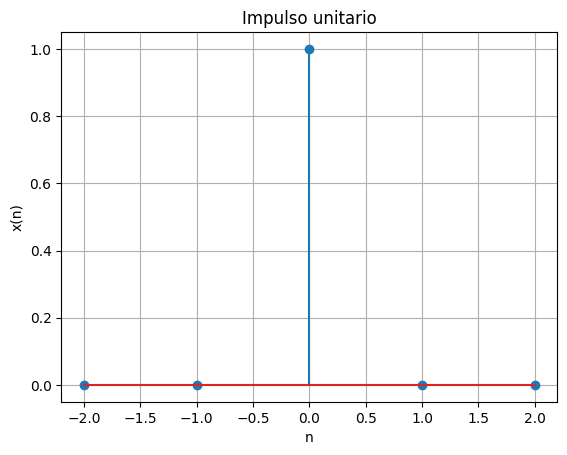

In [180]:
# Ejemplo impulso unitario

def impulso(n0, n1, n2):
 n = np.arange(n1,n2+1) # Se crea el vector de muestras
 x = (n-n0) == 0 # Genera x(n) = delta(n-n0); n1 <= n <= n2
 return [x,n]

x, n  = impulso(0,-2, 2)

# Gráfica del impulso unitario
plt.figure
plt.title('Impulso unitario')
plt.xlabel('n')
plt.ylabel('x(n)')
plt.grid()
plt.stem(n,x)

<StemContainer object of 3 artists>

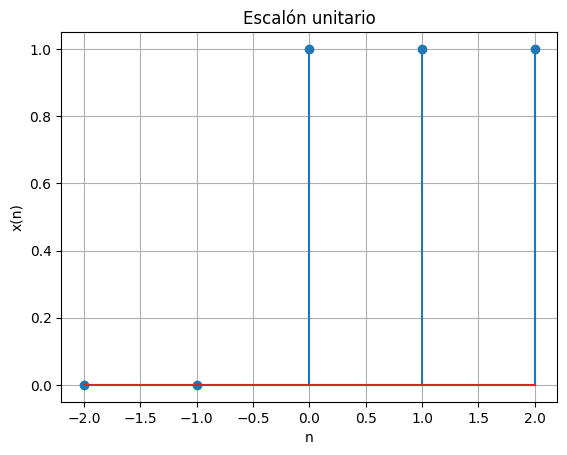

In [181]:
# Punto 1

def escalon(n0, n1, n2):
    n = np.arange(n1, n2+1) # Vector de muestras
    x = (n >= n0).astype(int) # Crea la señal: devuelve 1 si n >= n0, y 0 en caso contrario
    return x, n

x1, n1 = escalon(0,-2, 2)

# Gráfica del escalón unitario
plt.figure()
plt.title('Escalón unitario')
plt.xlabel('n')
plt.ylabel('x(n)')
plt.grid()
plt.stem(n1, x1)

<StemContainer object of 3 artists>

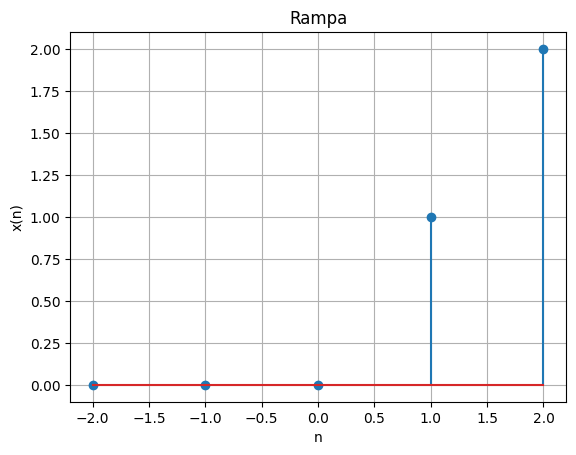

In [182]:
# Punto 2

# Opción 1: Solo sirve para números positivos

#def rampa(n0, n1, n2):
#  n = np.arange(n1, n2+1)
#  x = []
#  for i in range(len(n)):
#      if n[i] < n0:
#          x.append(0)
#      else:
#          x.append(np.abs(n[i]))
#  x = np.array(x)
#  return x, n

# Opción 2: Con np.maximun mostrado en clase

def rampa(n0, n1, n2):

    n = np.arange(n1, n2+1) # Vector de muestras
    x = np.maximum(0, n - n0)  # Genera una rampa: devuelve (n - n0) si es positivo, y 0 si es negativo

    return x, n

x2, n2 = rampa(0,-2, 2)

# Gráfica de la rampa
plt.figure()
plt.title('Rampa')
plt.xlabel('n')
plt.ylabel('x(n)')
plt.grid()
plt.stem(n2, x2)


<StemContainer object of 3 artists>

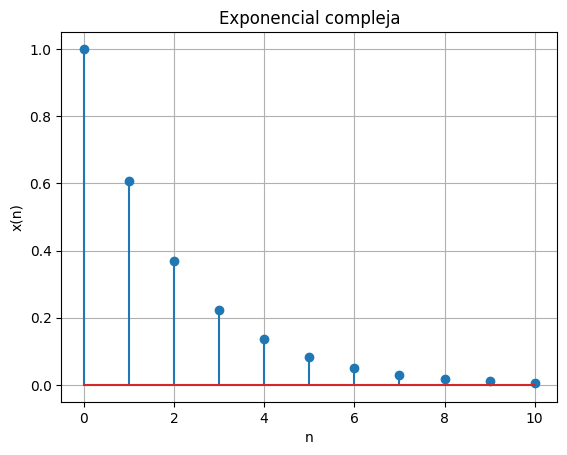

In [192]:
# Punto 3

def exponencial(sigma, w0, n1, n2):
    n = np.arange(n1, n2+1) # Vector de muestras
    x = np.exp((sigma + 1j*w0) * n) # Genera una señal exponencial compleja con atenuación/crecimiento (sigma) y frecuencia (w0)
    return x, n

x3, n3 = exponencial(-0.5, 10*np.pi, -0, 10)

# Gráfica de la exponencial compleja
plt.figure()
plt.title('Exponencial compleja')
plt.xlabel('n')
plt.ylabel('x(n)')
plt.grid()
plt.stem(n3, x3)

<StemContainer object of 3 artists>

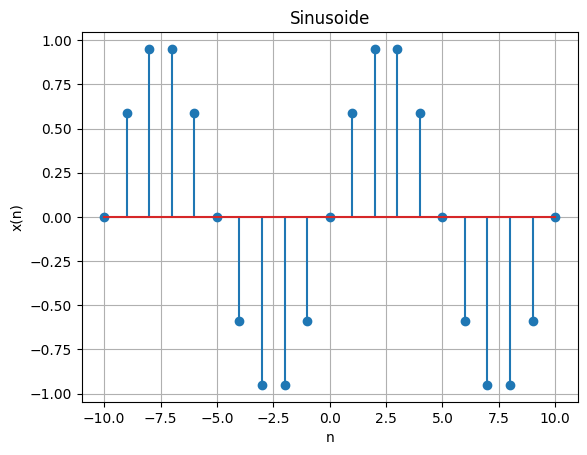

In [193]:
# Punto 4

def sinusoide(w0, theta0, n1, n2):

    n = np.arange(n1, n2+1) # Vector de muestras
    x = np.sin(w0*n + theta0) # Genera una señal seno con frecuencia angular w0 y fase inicial theta0

    return x, n

x4, n4 = sinusoide(0.2*np.pi, 0, -10, 10)

# Gráfica de la sinusoidal
plt.figure()
plt.title('Sinusoide')
plt.xlabel('n')
plt.ylabel('x(n)')
plt.grid()
plt.stem(n4, x4)

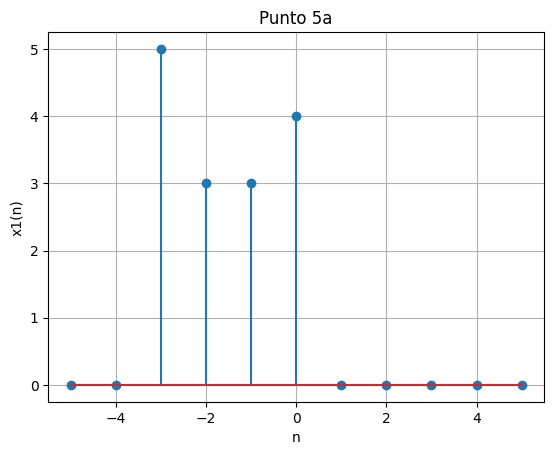

In [185]:
# Punto 5a

n5a1 = -5
n5a2 = 5

# Crea una señal sumando 5 impulsos con diferentes amplitudes y desplazamientos

x5a = (3*impulso(-1,n5a1,n5a2)[0] + 5*impulso(-3,n5a1,n5a2)[0] +
       3*impulso(-2,n5a1,n5a2)[0] + 3*impulso(0,n5a1,n5a2)[0] +
       impulso(0,n5a1,n5a2)[0])

n5a = np.arange(n5a1,n5a2+1) # Vector de muestras

# Gráfica señal del punto 5a - x1(n)
plt.stem(n5a,x5a)
plt.title("Punto 5a")
plt.xlabel("n")
plt.ylabel("x1(n)")
plt.grid()
plt.show()

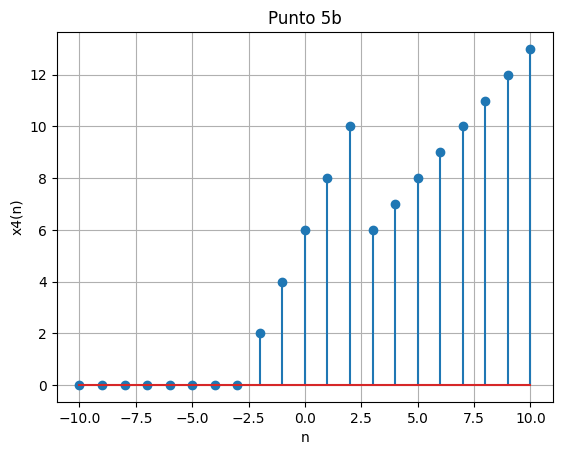

In [186]:
# Punto 5b

n5b1 = -10
n5b2 = 10

# Crea una señal sumando 2 impulsos y un escalón con diferentes amplitudes y desplazamientos

x5b = (2*rampa(-3,n5b1,n5b2)[0] - rampa(2,n5b1,n5b2)[0] -
      5*escalon(3,n5b1,n5b2)[0])

n5b = np.arange(n5b1,n5b2+1) # Vector de muestras

# Gráfica del punto 5b - x4(n)
plt.stem(n5b,x5b)
plt.title("Punto 5b")
plt.xlabel("n")
plt.ylabel("x4(n)")
plt.grid()
plt.show()


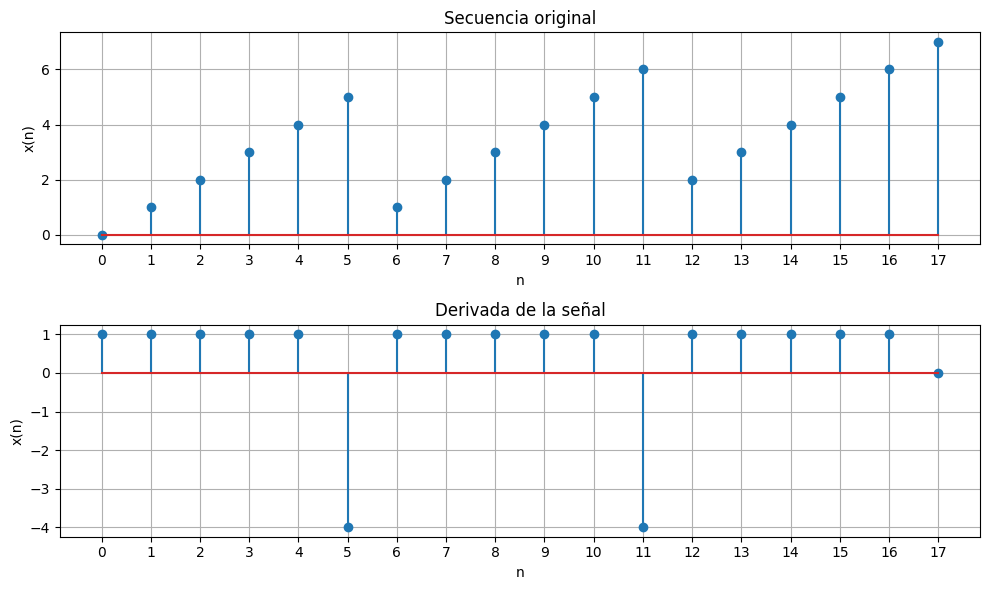

In [187]:
n6 = np.arange(0,18) # Vector de muestras

# Crea una señal concatenando tres segmentos de rampa diferentes
x6 = np.concatenate([rampa(0,0,5)[0], rampa(5,6,11)[0], rampa(10,12,17)[0]])

# Calcula la diferencia entre muestras adyacentes (derivada discreta)
derivada = np.diff(x6)
# Añade un 0 al final para que el vector mantenga la misma longitud que x6
derivada = np.append(derivada,0)

plt.figure(figsize=(10,6))

# Gráfica de la secuencia original
plt.subplot(2,1,1)
plt.stem(n6,x6)
plt.title("Secuencia original")
plt.xticks(np.arange(0,18,1))
plt.xlabel("n")
plt.ylabel("x(n)")
plt.grid()

# Gráfica de la derivada discreta
plt.subplot(2,1,2)
plt.stem(n6,derivada)
plt.title("Derivada de la señal")
plt.xlabel("n")
plt.ylabel("x(n)")
plt.grid()
plt.xticks(np.arange(0,18,1))

plt.tight_layout()

##**5b.** Describa lo que observa y el porqué no es exactamente la derivada del caso continuo.

Al comparar las dos gráficas se observa que: cuando la señal original aumenta de forma constante, la derivada toma valores constantes; cuando la señal no cambia, la derivada es cero; y, cuando aparecen cambios bruscos en los puntos donde la señal cambia su forma.

No es exactamente igual a la derivada del caso continuo porque la señal está formada por puntos separados y no por una curva continua. Por eso la derivada se calcula usando la diferencia entre valores consecutivos y solo aproxima el cambio de la señal.

Los cambios bruscos aparecen en los puntos donde la señal original cambia repentinamente su pendiente o su valor. Como la derivada discreta mide el cambio entre muestras consecutivas, esos cambios se reflejan como saltos o picos en la derivada.

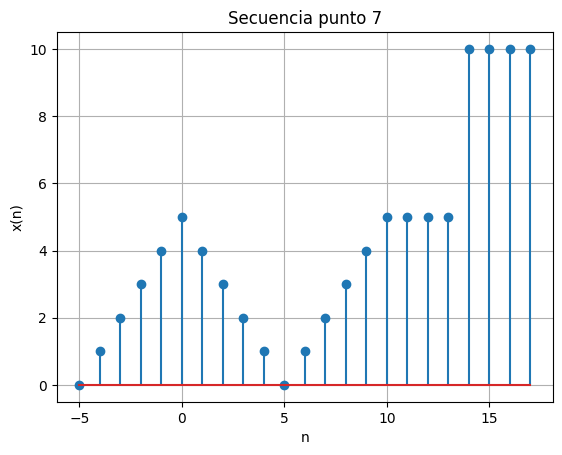

In [188]:
# Punto 7

x7 = np.array([0,1,2,3,4,5,4,3,2,1,0,1,2,3,4,5,5,5,5,10,10,10,10]) #El 5 con ^ indica donde está el cero
n7 = np.arange(-5,18) # Vector de muestras

# Gráfica secuencia del punto 7
plt.figure()
plt.stem(n7,x7)
plt.title("Secuencia punto 7")
plt.xlabel("n")
plt.ylabel("x(n)")
plt.grid()

Vector: [ 0  1  2  3  4  5  4  3  2  1  0  1  2  3  4  5  5  5  5 10 10 10 10]


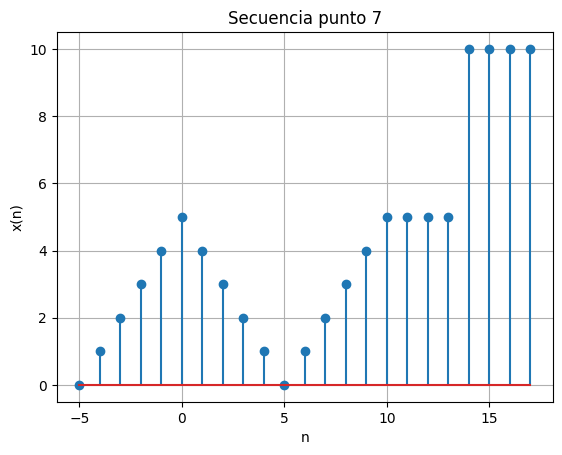

In [189]:
# Secuencia punto 7 hecha con las funciones ya implementadas
xn7 = np.concatenate([rampa(-5,-5,-1)[0], 5-rampa(0,0,4)[0], rampa(5,5,9)[0],
                      5*escalon(10,10,13)[0], 10*escalon(14,14,17)[0]])
print(f'Vector: {xn7}')

# Gráfica secuencia del punto 7 hecha con las funciones anteriores
plt.figure()
plt.stem(n7,xn7)
plt.title("Secuencia punto 7")
plt.xlabel("n")
plt.ylabel("x(n)")
plt.grid()

Vector: [ 0.  1.  2.  3.  4.  7.  8.  9. 10. 11.  8.  7.  6.  5.  4.  7.  9. 11.
 13. 20. 20. 20. 20. 20. 20. 20. 20.]


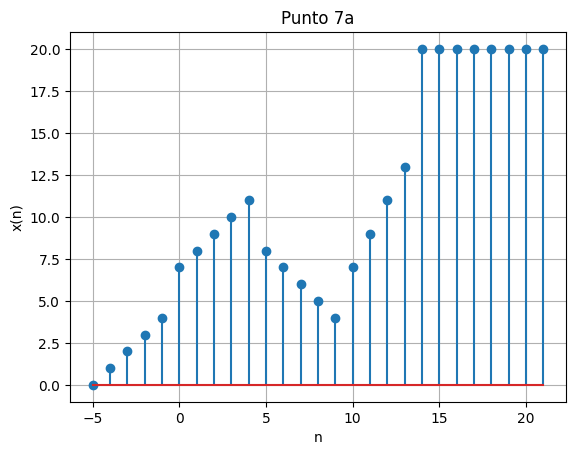

In [190]:
# Punto 7a

n7_desp = np.arange(-5,22) # Vector de muestras
x7_desp4 = np.concatenate((np.zeros(4), xn7)) # Secuencia anterior desplazada 4 puntos a la derecha

x7a = 2*x7_desp4 + (np.concatenate((xn7, np.zeros(4)))) # Secuencia x5(n)

print(f'Vector: {x7a}')

# Gráfica del punto 7a - x5(n)
plt.figure()
plt.stem(n7_desp,x7a)
plt.title("Punto 7a")
plt.xlabel("n")
plt.ylabel("x(n)")
plt.grid()

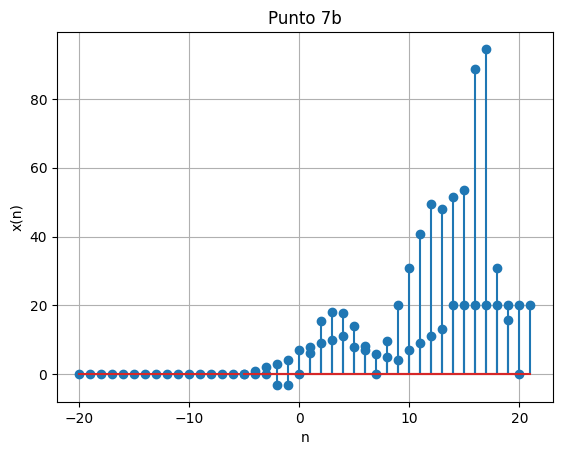

In [195]:
n7b = np.arange(-20,21) # Vector de muestras

x7nb = np.concatenate((np.zeros(15), xn7, np.zeros(3))) # Secuencia punto 7 más unos vectores de 0 para completar n = (-20,20)
x7_desp2 = np.concatenate((np.zeros(17), xn7, np.zeros(1))) # Vector anterior desplazado dos puntos

x7b = 0.001*np.exp(0.5*n7b)*x7nb + 10*np.sin(0.05*np.pi*n7b)*x7_desp2

# Gráfica del punto 7b - x6(n)
plt.figure()
plt.stem(n7b,x7b)
plt.stem(n7_desp,x7a)
plt.title("Punto 7b")
plt.xlabel("n")
plt.ylabel("x(n)")
plt.grid()